# PE-AV Embedding Analysis: RDMs and Single vs Joint Modality

Load PE-AV embeddings, compute representational discosine_similarity matrices (RDMs), and compare single vs joint modality embeddings for audio/video.

In [14]:
from pathlib import Path
from typing import List, Tuple, Dict, Any
from typing import Tuple
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# Configuration
PEAV_RUNS = [
    {
        "label": "pe-av-small-16-frame",
        "model_name": "PE-AV Small 16F",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame"),
    },
    {
        "label": "pe-av-large",
        "model_name": "PE-AV Large",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large"),
    },
]

ALPHA = 0.05

## Core Functions

In [15]:
def load_modality_embeddings(emb_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load audio and video and joint embeddings from NPZ file."""
    emb_dir = emb_dir.expanduser().resolve()
    if not emb_dir.exists():
        raise FileNotFoundError(f"Missing embeddings directory: {emb_dir}")
    
    npz_files = list(emb_dir.glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {emb_dir}")
    
    npz_file = npz_files[0]
    print(f"Loading: {npz_file.name}")
    data = np.load(npz_file)
    
    if "audio" not in data or "video" not in data:
        raise KeyError("NPZ must contain 'audio' and 'video' arrays")
    
    audio = data["audio"]
    video = data["video"]
    joint = data["av"]
    if (audio.shape[0] != video.shape[0]) | (audio.shape[0] != joint.shape[0]):
        raise ValueError(
            f"Segment count mismatch: audio={audio.shape[0]} video={video.shape[0]}"
        )
    
    print(f"  Audio shape: {audio.shape}, Video shape: {video.shape}, joint shape: {audio.shape}")
    return audio, video, joint


def compute_rdm(embeddings: np.ndarray, metric: str = "correlation") -> np.ndarray:
    """Compute representational dissimilarity matrix using scipy.spatial.distance.pdist."""
    if metric not in ["correlation", "cosine"]:
        raise ValueError(f"Unknown metric: {metric}")
    s = embeddings.shape
    if len(s) == 1:
        embeddings = embeddings.reshape(-1, 1)
    rdm = squareform(pdist(embeddings, metric=metric))
    return rdm


def plot_rdm(
    rdm: np.ndarray,
    out_path: Path,
    title: str,
    metric: str = "correlation",
    figsize: Tuple[int, int] = (6, 5),
) -> None:
    """Plot RDM heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(rdm, origin="upper", cmap="coolwarm")
    
    cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label(f"Dissimilarity ({metric})", fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Segment index", fontsize=10)
    ax.set_ylabel("Segment index", fontsize=10)
    
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")



def plot_av_similarity_heatmap(
    sim: np.ndarray,
    out_path: Path,
    title: str,
    vmin: float = None,
    vmax: float = None,
    figsize: Tuple[int, int] = (6, 5),
) -> None:
    """Plot audio-video cross-similarity heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if vmin is None:
        vmin = np.nanmin(sim)
    if vmax is None:
        vmax = np.nanmax(sim)
    
    im = ax.imshow(sim, origin="upper", cmap="coolwarm", vmin=vmin, vmax=vmax)
    
    cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Cosine similarity", fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Video segment index", fontsize=10)
    ax.set_ylabel("Audio segment index", fontsize=10)
    
    fig.tight_layout()
    if out_path is not None:
        out_path = out_path.expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


def compute_diag_stats(sim: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute diagonal vs off-diagonal statistics."""
    diag = np.diag(sim)
    
    # Mask diagonal to compute off-diagonal stats
    mask = ~np.eye(sim.shape[0], dtype=bool)
    off_mean = np.array([sim[i, mask[i]].mean() for i in range(sim.shape[0])])
    off_se = np.array([stats.sem(sim[i, mask[i]]) for i in range(sim.shape[0])])
    
    return diag, off_mean, off_se


def plot_diag_stats(
    diag: np.ndarray,
    off_mean: np.ndarray,
    off_se: np.ndarray,
    sig_indices: List[int],
    out_path: Path,
    title: str,
    alpha: float,
):
    """Plot diagonal vs off-diagonal with optional significance markers."""
    x = np.arange(len(diag))
    fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(x, diag, label="Diagonal (same segment)", color="C0", linewidth=1.5)
    ax.plot(x, off_mean, label="Off-diagonal mean", color="C1", linewidth=1.5)
    ax.fill_between(x, off_mean - off_se, off_mean + off_se, 
                     color="C1", alpha=0.3, label="Off-diagonal ±1 SE")
    
    if sig_indices:
        ax.scatter(sig_indices, diag[sig_indices], marker="*", 
                   color="red", s=150, zorder=3, edgecolor="black",
                   label=f"Significant (p < {alpha})")
    
    ax.set_xlabel("Segment index", fontsize=11)
    ax.set_ylabel("Cosine similarity", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")


def find_significant_segments(sim: np.ndarray, alpha: float = 0.05) -> List[int]:
    """Find segments where diagonal > off-diagonal (one-sided t-test)."""
    n = sim.shape[0]
    sig_indices = []
    
    for i in range(n):
        diag_val = sim[i, i]
        off_vals = np.concatenate([sim[i, :i], sim[i, i+1:]])
        
        if len(off_vals) == 0:
            continue
        
        # One-sided t-test: H1: diag_val > mean(off_vals)
        t_stat, p_val = stats.ttest_1samp(off_vals, diag_val, alternative='less')
        
        if p_val < alpha and diag_val > off_vals.mean():
            sig_indices.append(i)
    
    return sig_indices

## Similarity and RDM Analysis


Processing: PE-AV Small 16F
Loading: pe-av-small-16-frame_2s.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=-0.003, std=0.078
Video embeddings: shape=(1581, 1024), mean=0.001, std=0.101
Joint embeddings: shape=(1581, 1024), mean=-0.000, std=0.094

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.160, max=0.205, mean=0.023
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.795, max=1.160, mean=0.977

[2/5] Plotting similarity and correlation distance heatmaps...
Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_av_similarity.png


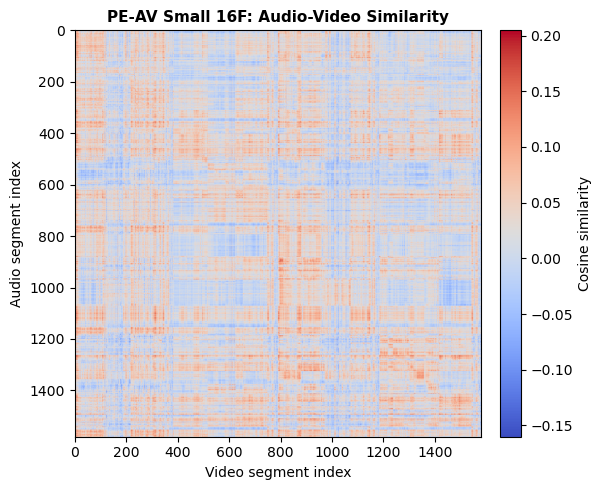

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_av_similarity.png


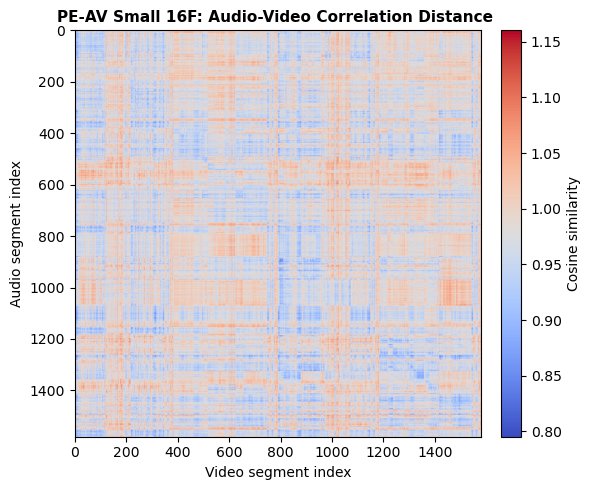


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.061, std=0.035
Off-diagonal: mean=0.023, std=0.020


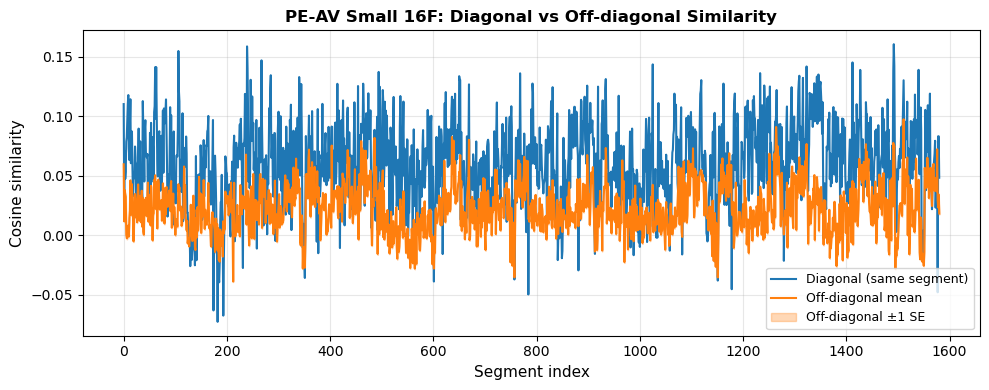

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


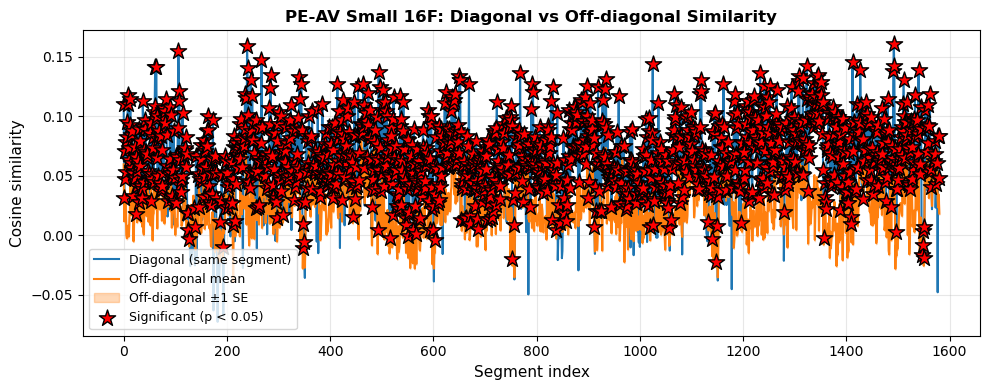

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_significant_segments.txt

[5/5] Computing RDMs...


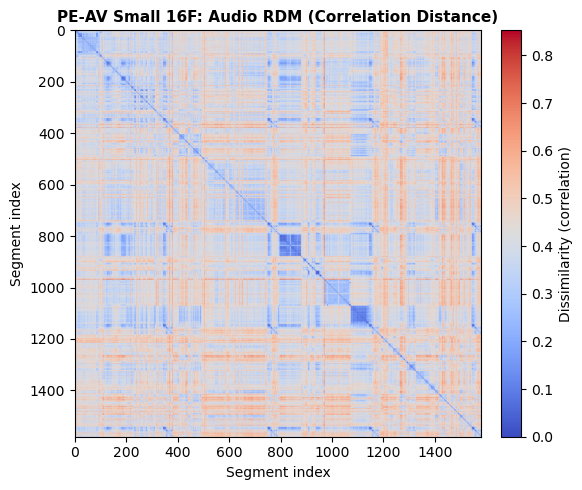

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_audio.png


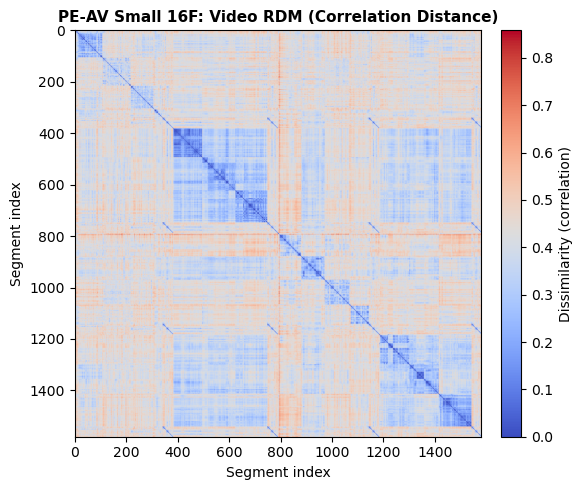

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_video.png


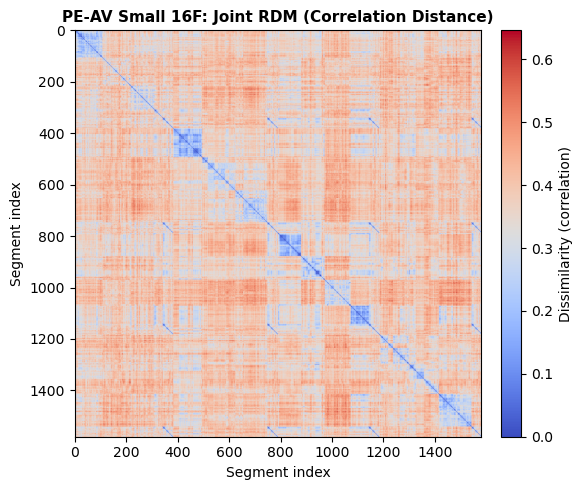

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_video.png

RESULTS SUMMARY FOR PE-AV Small 16F
Total segments: 1581
Significant segments: 1404 (88.8%)
Mean diagonal similarity: 0.061 ± 0.035
Mean off-diagonal similarity: 0.023 ± 0.020
Diagonal - Off-diagonal: 0.038

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame


Processing: PE-AV Large
Loading: pe-av-large_2s.npz
  Audio shape: (1503, 1024), Video shape: (1503, 1024), joint shape: (1503, 1024)

Audio embeddings: shape=(1503, 1024), mean=0.003, std=0.083
Video embeddings: shape=(1503, 1024), mean=0.003, std=0.111
Joint embeddings: shape=(1503, 1024), mean=0.004, std=0.112

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1503, 1503), min=-0.136, max=0.228, mean=0.006
Pearson Correlation distance matrix: shape=(1503, 1503), min=0.773, max=1.138, mean=0.995

[2/5] Plotting similar

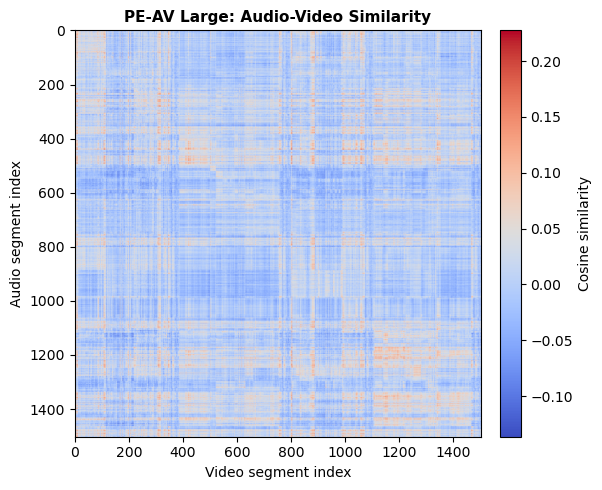

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_av_similarity.png


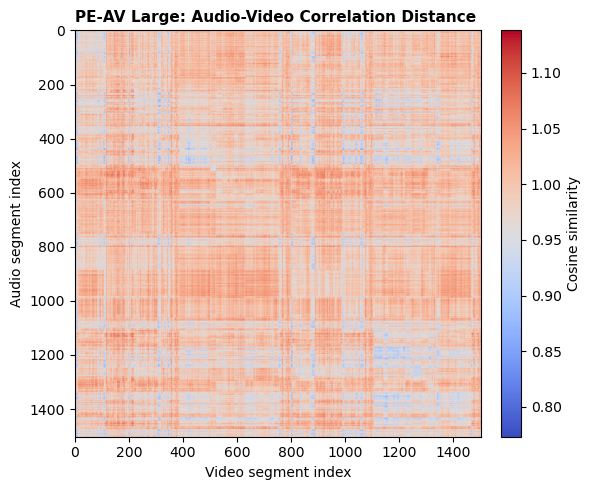


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.038, std=0.035
Off-diagonal: mean=0.006, std=0.022


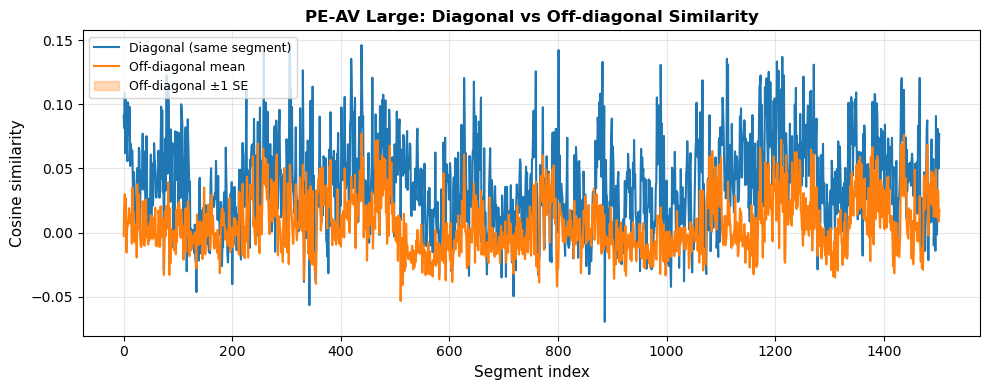

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


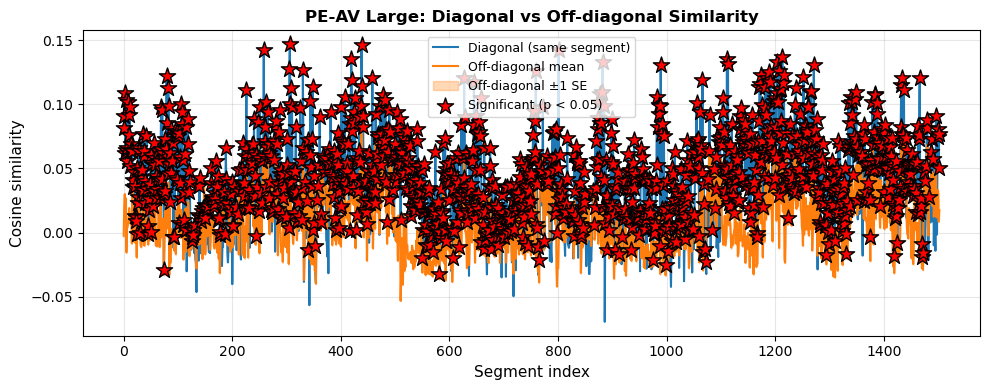

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_significant_segments.txt

[5/5] Computing RDMs...


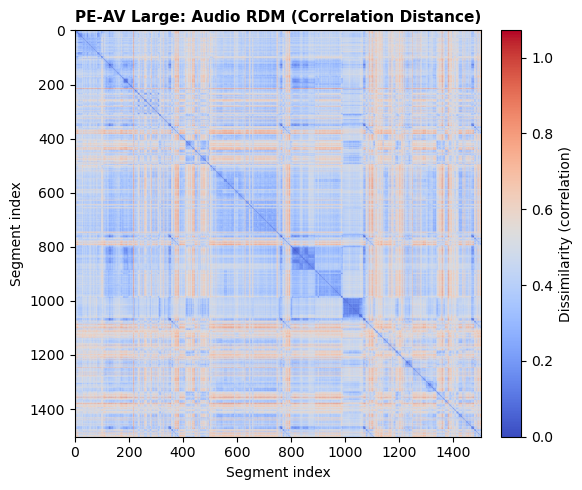

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_audio.png


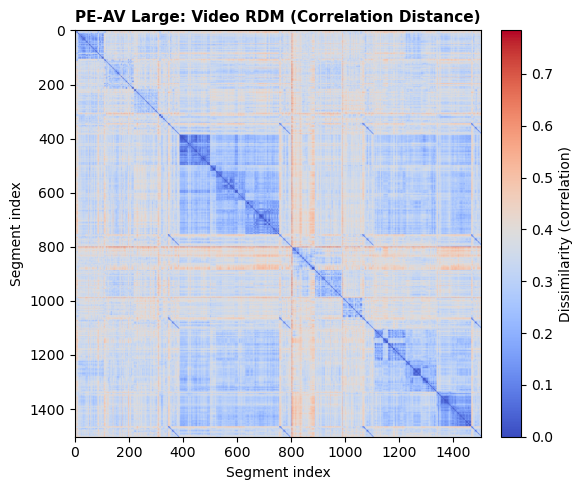

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_video.png


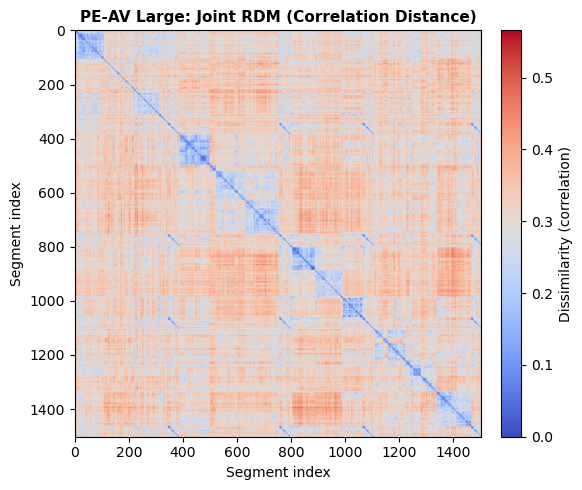

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_video.png

RESULTS SUMMARY FOR PE-AV Large
Total segments: 1503
Significant segments: 1274 (84.8%)
Mean diagonal similarity: 0.038 ± 0.035
Mean off-diagonal similarity: 0.006 ± 0.022
Diagonal - Off-diagonal: 0.032

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large



In [18]:
# Compute RDMs, similarity matrices, and significance analysis for each PE-AV run
for run in PEAV_RUNS:
    print(f"\n{'='*70}")
    print(f"Processing: {run['model_name']}")
    print(f"{'='*70}")
    
    # Load embeddings
    audio, video, joint = load_modality_embeddings(run["emb_dir"])
    out_dir = run["emb_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    
    label = run['label']
    model_name = run['model_name']
    alpha = 0.05
    
    # Print embedding statistics
    print(f"\nAudio embeddings: shape={audio.shape}, "
          f"mean={audio.mean():.3f}, std={audio.std():.3f}")
    print(f"Video embeddings: shape={video.shape}, "
          f"mean={video.mean():.3f}, std={video.std():.3f}")
    print(f"Joint embeddings: shape={joint.shape}, "
          f"mean={joint.mean():.3f}, std={joint.std():.3f}")

    # ========== 1. COMPUTE AUDIO-VIDEO COSINE SIMILARITY ==========
    print("\n[1/5] Computing audio-video cosine similarity...")
    sim = cosine_similarity(audio, video)
    corr_dist = cdist(audio, video, metric='correlation')

    print(f"Similarity matrix: shape={sim.shape}, "
          f"min={sim.min():.3f}, max={sim.max():.3f}, mean={sim.mean():.3f}")
    
    print(f"Pearson Correlation distance matrix: shape={corr_dist.shape}, "
          f"min={corr_dist.min():.3f}, max={corr_dist.max():.3f}, mean={corr_dist.mean():.3f}")
    
    
    # Save similarity matrix
    np.save(out_dir / f"{label}_av_similarity.npy", sim.astype(np.float32))
    
    # ========== 2. PLOT SIMILARITY HEATMAPS ==========
    print("\n[2/5] Plotting similarity and correlation distance heatmaps...")
    plot_av_similarity_heatmap(
        sim,
        out_dir / f"{label}_av_similarity.png",
        f"{model_name}: Audio-Video Similarity",
    )
    plot_av_similarity_heatmap(
        corr_dist,
        out_dir / f"{label}_av_similarity.png",
        f"{model_name}: Audio-Video Correlation Distance ",
    )
    
    # ========== 3. COMPUTE DIAGONAL STATISTICS ==========
    print("\n[3/5] Computing diagonal vs off-diagonal statistics...")
    diag, off_mean, off_se = compute_diag_stats(sim)
    
    print(f"Diagonal: mean={diag.mean():.3f}, std={diag.std():.3f}")
    print(f"Off-diagonal: mean={off_mean.mean():.3f}, std={off_mean.std():.3f}")
    sig_indices = None
    plot_diag_stats(
        diag,
        off_mean,
        off_se,
        sig_indices,
        out_dir / f"{label}_diag_analysis.png",
        f"{model_name}: Diagonal vs Off-diagonal Similarity",
        alpha=alpha
    )
    
    # ========== 4. FIND SIGNIFICANT SEGMENTS & PLOT ==========
    print(f"\n[4/5] Finding significant segments (alpha={alpha})...")
    sig_indices = find_significant_segments(sim, alpha=alpha)
    
    # Plot diagonal analysis with significance markers
    plot_diag_stats(
        diag,
        off_mean,
        off_se,
        sig_indices,
        out_dir / f"{label}_diag_analysis.png",
        f"{model_name}: Diagonal vs Off-diagonal Similarity",
        alpha=alpha
    )
    
    # Save significant segments
    sig_path_npy = out_dir / f"{label}_significant_segments.npy"
    sig_path_txt = out_dir / f"{label}_significant_segments.txt"
    
    np.save(sig_path_npy, np.array(sig_indices, dtype=np.int64))
    
    with open(sig_path_txt, "w") as f:
        f.write(f"# Significant segments (diag > off-diag, p < {alpha})\n")
        f.write(f"# Total: {len(sig_indices)} / {len(diag)} segments\n")
        f.write(f"# Segment indices (0-based):\n")
        f.write(",".join(str(idx) for idx in sig_indices))
    print(f"Saved significant segments to: {sig_path_npy} and {sig_path_txt}")
    # ========== 5. COMPUTE RDMs (Correlation Distance) ==========
    print("\n[5/5] Computing RDMs...")
    rdm_audio = compute_rdm(audio, metric="correlation")
    rdm_video = compute_rdm(video, metric="correlation")
    rdm_joint = compute_rdm(joint, metric="correlation")

    
    # Save RDMs
    np.save(out_dir / f"{label}_rdm_audio.npy", rdm_audio.astype(np.float32))
    np.save(out_dir / f"{label}_rdm_video.npy", rdm_video.astype(np.float32))
    
    # Plot RDMs
    plot_rdm(
        rdm_audio,
        out_dir / f"{label}_rdm_audio.png",
        f"{model_name}: Audio RDM (Correlation Distance)",
        metric="correlation",
    )
    
    plot_rdm(
        rdm_video,
        out_dir / f"{label}_rdm_video.png",
        f"{model_name}: Video RDM (Correlation Distance)",
        metric="correlation",
    )
    plot_rdm(
        rdm_joint,
        out_dir / f"{label}_rdm_video.png",
        f"{model_name}: Joint RDM (Correlation Distance)",
        metric="correlation",
    )
    
    # ========== SUMMARY ==========
    print(f"\n{'='*70}")
    print(f"RESULTS SUMMARY FOR {model_name}")
    print(f"{'='*70}")
    print(f"Total segments: {len(diag)}")
    print(f"Significant segments: {len(sig_indices)} ({100*len(sig_indices)/len(diag):.1f}%)")
    print(f"Mean diagonal similarity: {diag.mean():.3f} ± {diag.std():.3f}")
    print(f"Mean off-diagonal similarity: {off_mean.mean():.3f} ± {off_mean.std():.3f}")
    print(f"Diagonal - Off-diagonal: {(diag.mean() - off_mean.mean()):.3f}")
    print(f"\nAll outputs saved to: {out_dir}")
    print(f"{'='*70}\n")